# NeuralGCM 6h Forecast — Local Data Demo

Adapted from the official inference demo, using:
- **Local model weights** (`assets/weights/neuralgcm/`)
- **Pre-processed Gaussian-grid input** (`assets/data/processed_neuralgcm/input_{date}_gaussian.nc`)
- **Raw ERA5 ground truth** (`assets/data/raw/upper_{valid_date}.nc`)

Evaluates **WRMSE** for: `z500`, `t850`, `u850`  
> ⚠️ NeuralGCM only outputs **pressure-level** variables. `t2m` is not available.

In [3]:
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import jax
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from dinosaur import horizontal_interpolation, spherical_harmonic, xarray_utils
import neuralgcm

# ── Paths ──────────────────────────────────────────────────────────────────
BASE        = Path('/home/NWP-Benchmark')
WEIGHTS_DIR = BASE / 'assets' / 'weights'  / 'neuralgcm'
DATA_DIR    = BASE / 'assets' / 'data'
PROC_DIR    = DATA_DIR / 'processed_neuralgcm'
RAW_DIR     = DATA_DIR / 'raw'

# ── Forecast settings ──────────────────────────────────────────────────────
INIT_DATE   = '2023010112'          # YYYYMMDDHH
LEAD_HOURS  = 6
MODEL_RES   = '0.7'                 # '0.7' | '1.4' | '2.8'

MODEL_FILES = {
    '0.7': 'models_v1_deterministic_0_7_deg.pkl',
    '1.4': 'models_v1_deterministic_1_4_deg.pkl',
    '2.8': 'models_v1_deterministic_2_8_deg.pkl',
}

init_time  = pd.to_datetime(INIT_DATE, format='%Y%m%d%H')
valid_time = init_time + pd.Timedelta(hours=LEAD_HOURS)
valid_str  = valid_time.strftime('%Y%m%d%H')

print(f'Init : {init_time}')
print(f'Valid: {valid_time}  (+{LEAD_HOURS}h)')
print(f'JAX devices: {jax.devices()}')

Init : 2023-01-01 12:00:00
Valid: 2023-01-01 18:00:00  (+6h)
JAX devices: [cuda(id=0)]


## 1. Load model

In [4]:
ckpt_path = WEIGHTS_DIR / MODEL_FILES[MODEL_RES]
print(f'Loading checkpoint: {ckpt_path.name}')

with open(ckpt_path, 'rb') as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

print(f'Model timestep    : {model.timestep}')
print(f'Input variables   : {model.input_variables}')
print(f'Forcing variables : {model.forcing_variables}')
print(f'Native grid       : {model.data_coords.horizontal.longitude_nodes}'
      f'×{model.data_coords.horizontal.latitude_nodes}')

Loading checkpoint: models_v1_deterministic_0_7_deg.pkl
Model timestep    : 3600 seconds
Input variables   : ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
Forcing variables : ['sea_ice_cover', 'sea_surface_temperature']
Native grid       : 512×256


## 2. Load & regrid initial conditions

We use the pre-processed Gaussian-grid file from `prepare.py`.
If it doesn't exist, we fall back to re-gridding raw ERA5 on-the-fly
(same approach as the official demo).

In [5]:
proc_path = PROC_DIR / f'input_{INIT_DATE}_gaussian.nc'

if proc_path.exists():
    print(f'[✓] Using pre-processed file: {proc_path.name}')
    ds_input = xr.open_dataset(proc_path)
    if 'valid_time'    in ds_input.dims: ds_input = ds_input.rename({'valid_time': 'time'})
    if 'pressure_level' in ds_input.dims: ds_input = ds_input.rename({'pressure_level': 'level'})
else:
    print('[!] Pre-processed file not found — re-gridding from raw ERA5...')
    upper = xr.open_dataset(RAW_DIR / f'upper_{INIT_DATE}.nc')
    surf  = xr.open_dataset(RAW_DIR / f'surface_{INIT_DATE}.nc')
    for ds in [upper, surf]:
        if 'valid_time'    in ds.dims: ds.rename({'valid_time': 'time'})
        if 'pressure_level' in ds.dims: ds.rename({'pressure_level': 'level'})
    var_map = {'z':'geopotential','t':'temperature','u':'u_component_of_wind',
               'v':'v_component_of_wind','q':'specific_humidity',
               'ciwc':'specific_cloud_ice_water_content',
               'clwc':'specific_cloud_liquid_water_content',
               'sst':'sea_surface_temperature','siconc':'sea_ice_cover'}
    upper = upper.rename({k:v for k,v in var_map.items() if k in upper})
    surf  = surf.rename ({k:v for k,v in var_map.items() if k in surf})
    ds_raw = xr.merge([upper, surf], compat='override')
    ds_raw = ds_raw[[v for v in model.input_variables+model.forcing_variables if v in ds_raw]]
    if ds_raw.level.values[0] > ds_raw.level.values[-1]:
        ds_raw = ds_raw.isel(level=slice(None, None, -1))
    era5_grid = spherical_harmonic.Grid(
        latitude_nodes  = ds_raw.sizes['latitude'],
        longitude_nodes = ds_raw.sizes['longitude'],
        latitude_spacing  = xarray_utils.infer_latitude_spacing(ds_raw.latitude),
        longitude_offset  = xarray_utils.infer_longitude_offset(ds_raw.longitude),
    )
    regridder = horizontal_interpolation.ConservativeRegridder(
        era5_grid, model.data_coords.horizontal, skipna=True)
    ds_input = xarray_utils.regrid(ds_raw, regridder)
    ds_input = xarray_utils.fill_nan_with_nearest(ds_input)

print(f'Grid  : {ds_input.sizes["longitude"]}×{ds_input.sizes["latitude"]}')
print(f'Levels: {ds_input.sizes["level"]}  ({float(ds_input.level[0]):.0f}→{float(ds_input.level[-1]):.0f} hPa)')
print(f'Times : {[str(t)[:19] for t in ds_input.time.values]}')

[✓] Using pre-processed file: input_2023010112_gaussian.nc
Grid  : 512×256
Levels: 37  (1→1000 hPa)
Times : ['2023-01-01T06:00:00', '2023-01-01T12:00:00']


## 3. Encode initial state

In [6]:
init_np = np.datetime64(init_time)
ds_init = ds_input.sel(time=init_np, method='nearest')

inputs         = model.inputs_from_xarray(ds_init)
input_forcings = model.forcings_from_xarray(ds_init)
rng_key        = jax.random.key(42)

print('Encoding initial state...')
initial_state = model.encode(inputs, input_forcings, rng_key)
print('Done.')

# Persistence forcings (SST / SIC fixed at init time — standard for short forecasts)
all_forcings = model.forcings_from_xarray(
    ds_input.sel(time=[init_np], method='nearest'))

Encoding initial state...
Done.


## 4. Run 6h forecast

`model.timestep = 1h`, so 6h = 6 steps.  
We save outputs at every hour and take the last frame (`t+6h`).

In [7]:
dt_hours = model.timestep / np.timedelta64(1, 'h')      # 1.0
n_steps  = int(LEAD_HOURS / dt_hours)                   # 6
print(f'model.timestep={dt_hours:.0f}h  →  n_steps={n_steps}')

# Output timestamps: t+1h … t+6h
out_times = np.array(
    [init_time + pd.Timedelta(hours=(i+1)*dt_hours) for i in range(n_steps)],
    dtype='datetime64[ns]')

print('Running forecast...')
_, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps       = n_steps,
    timedelta   = model.timestep,   # 1h per outer step
    start_with_input = False,
)
print('Done.')

# Full trajectory and last frame (t+6h)
pred_traj = model.data_to_xarray(predictions, times=out_times)
pred_6h   = pred_traj.isel(time=-1)

print(f'Prediction valid time : {str(pred_traj.time.values[-1])[:19]}')
print(f'Output variables      : {list(pred_6h.data_vars)}')

model.timestep=1h  →  n_steps=6
Running forecast...
Done.
Prediction valid time : 2023-01-01T18:00:00
Output variables      : ['sim_time', 'specific_humidity', 'geopotential', 'u_component_of_wind', 'temperature', 'specific_cloud_liquid_water_content', 'specific_cloud_ice_water_content', 'v_component_of_wind']


## 5. Load ground truth & regrid to native resolution

In [8]:
gt_path = RAW_DIR / f'upper_{valid_str}.nc'
assert gt_path.exists(), f'Ground-truth file not found: {gt_path}'

ds_gt = xr.open_dataset(gt_path)
if 'valid_time'    in ds_gt.dims: ds_gt = ds_gt.rename({'valid_time': 'time'})
if 'pressure_level' in ds_gt.dims: ds_gt = ds_gt.rename({'pressure_level': 'level'})
var_map_gt = {'z':'geopotential','t':'temperature','u':'u_component_of_wind',
              'v':'v_component_of_wind'}
ds_gt = ds_gt.rename({k:v for k,v in var_map_gt.items() if k in ds_gt})

# Sort levels ascending
if float(ds_gt.level.values[0]) > float(ds_gt.level.values[-1]):
    ds_gt = ds_gt.isel(level=slice(None, None, -1))

valid_np = np.datetime64(valid_time)
ds_gt_sel = ds_gt.sel(time=valid_np, method='nearest')

# Regrid ERA5 0.25° → NeuralGCM Gaussian grid
gt_era5_grid = spherical_harmonic.Grid(
    latitude_nodes  = ds_gt_sel.sizes['latitude'],
    longitude_nodes = ds_gt_sel.sizes['longitude'],
    latitude_spacing  = xarray_utils.infer_latitude_spacing(ds_gt_sel.latitude),
    longitude_offset  = xarray_utils.infer_longitude_offset(ds_gt_sel.longitude),
)
gt_regridder = horizontal_interpolation.ConservativeRegridder(
    gt_era5_grid, model.data_coords.horizontal)
ds_gt_native = xarray_utils.regrid(ds_gt_sel, gt_regridder)
ds_gt_native = xarray_utils.fill_nan_with_nearest(ds_gt_native)

print(f'GT valid time : {str(ds_gt_sel.time.values)[:19]}')
print(f'GT grid (native): {ds_gt_native.sizes["longitude"]}×{ds_gt_native.sizes["latitude"]}')

GT valid time : 2023-01-01T18:00:00
GT grid (native): 512×256


## 6. WRMSE evaluation

$$\text{WRMSE} = \sqrt{\frac{\sum_i w_i (\hat{y}_i - y_i)^2}{\sum_i w_i}}, \quad w_i = \cos(\phi_i)$$

In [10]:
def wrmse(pred: xr.DataArray, gt: xr.DataArray) -> float:
    """Latitude-weighted RMSE over the full globe."""
    lat = gt['latitude']
    w   = np.cos(np.deg2rad(lat))
    w   = w / w.mean()
    diff_sq = (pred - gt) ** 2
    return float(np.sqrt(diff_sq.weighted(w).mean()))

# Variables to evaluate: (long_name, level_hPa)
# Note: t2m is NOT a NeuralGCM output — model only predicts pressure-level fields
EVAL_VARS = [
    ('geopotential',      500, 'z500',  'm²/s²'),
    ('temperature',       850, 't850',  'K'),
    ('u_component_of_wind', 850, 'u850', 'm/s'),
]

print(f'{"Variable":<8}  {"WRMSE":>10}  Unit')
print('-' * 35)
results = {}
for var, lev, label, unit in EVAL_VARS:
    if var not in pred_6h or var not in ds_gt_native:
        print(f'{label:<8}  NOT AVAILABLE')
        continue
    da_pred = pred_6h[var].sel(level=lev).squeeze()
    da_gt   = ds_gt_native[var].sel(level=lev).squeeze()
    score   = wrmse(da_pred, da_gt)
    results[label] = score
    extra = f'  ({score/9.80665:.2f} gpm)' if var == 'geopotential' else ''
    print(f'{label:<8}  {score:>10.4f}  {unit}{extra}')

print()
print('⚠  t2m: NeuralGCM does not predict 2-metre temperature (surface diagnostic).')

Variable       WRMSE  Unit
-----------------------------------
z500         50.7571  m²/s²  (5.18 gpm)
t850          0.3141  K
u850          0.5844  m/s

⚠  t2m: NeuralGCM does not predict 2-metre temperature (surface diagnostic).


## 7. Visualisation: prediction vs ERA5 (z500, t850, u850)

Saved: /home/NWP-Benchmark/outputs/neuralgcm/demo_6h_2023010112.png


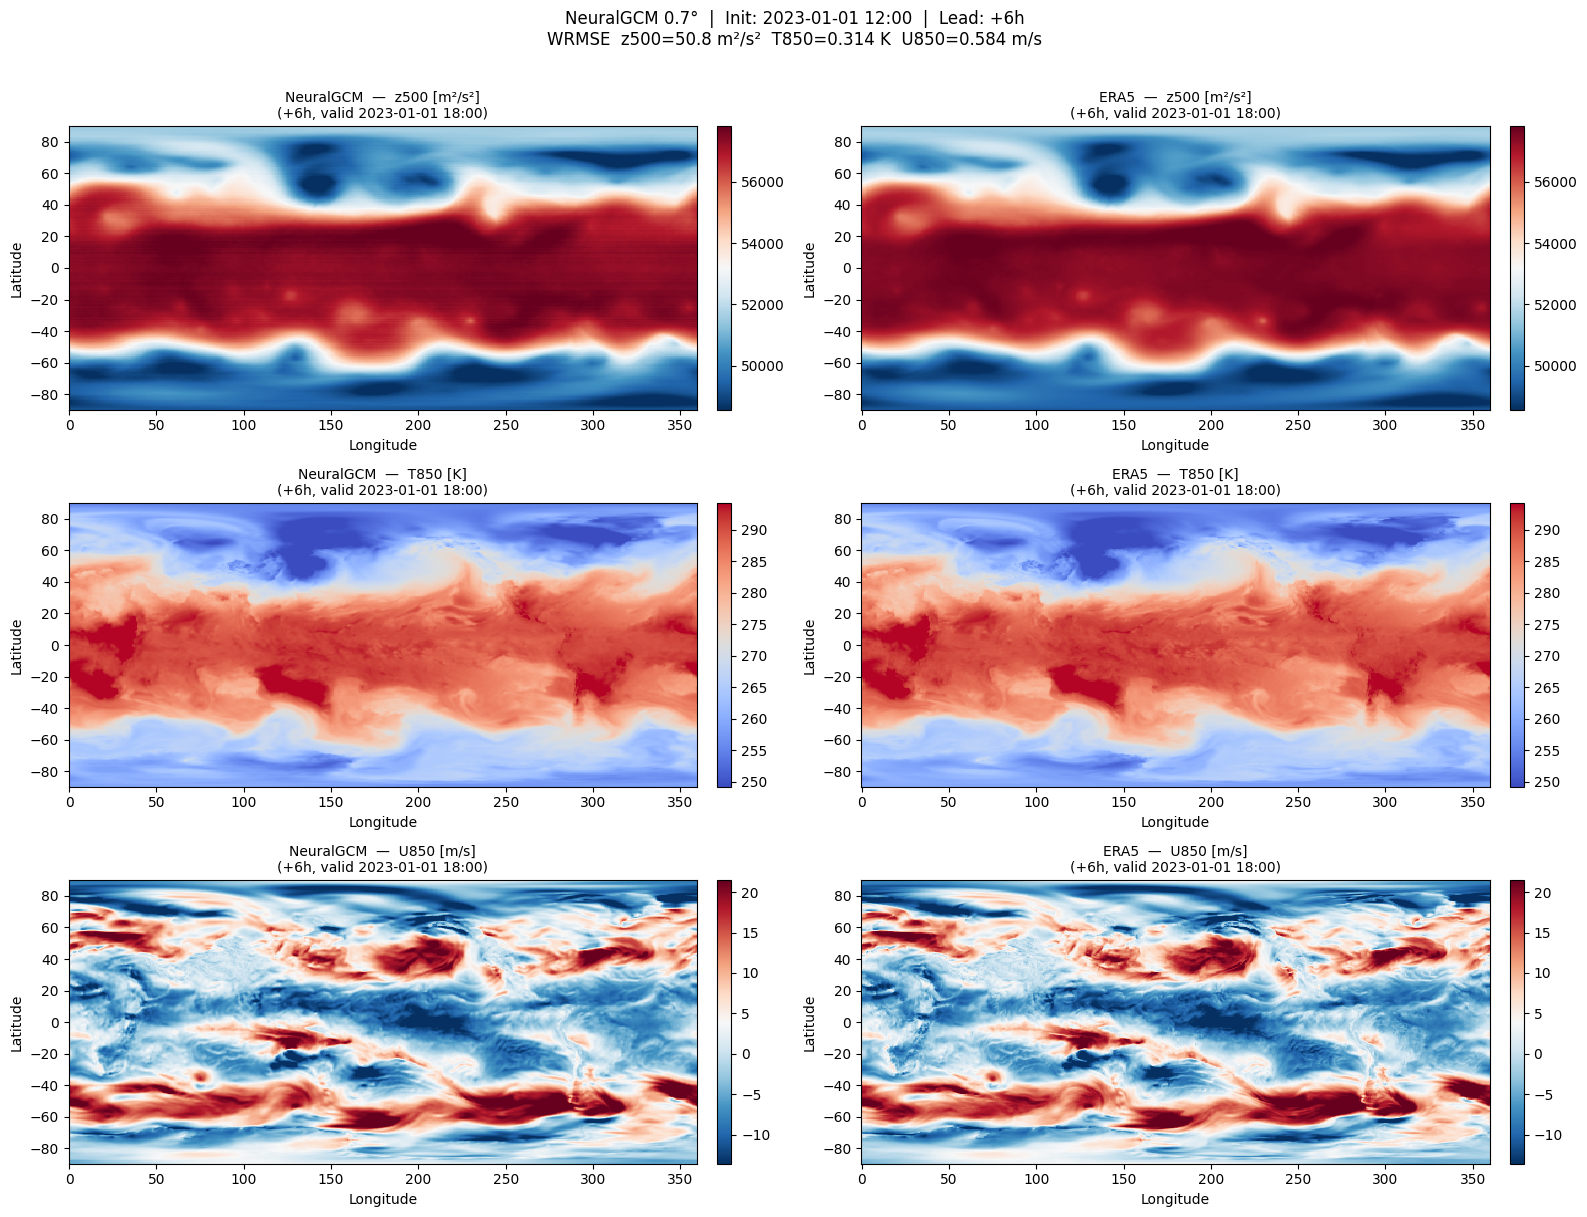

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12),
                         subplot_kw={'projection': None})

PLOT_VARS = [
    ('geopotential',        500, 'z500 [m²/s²]',  'RdBu_r'),
    ('temperature',         850, 'T850 [K]',       'coolwarm'),
    ('u_component_of_wind', 850, 'U850 [m/s]',     'RdBu_r'),
]

lon = pred_6h.longitude.values
lat = pred_6h.latitude.values

for row, (var, lev, title, cmap) in enumerate(PLOT_VARS):
    p_data = pred_6h[var].sel(level=lev).squeeze().values.T      # (lat, lon)
    g_data = ds_gt_native[var].sel(level=lev).squeeze().values.T

    vmin = np.percentile(g_data, 2)
    vmax = np.percentile(g_data, 98)
    norm = mcolors.TwoSlopeNorm(vcenter=(vmin+vmax)/2, vmin=vmin, vmax=vmax)

    for col, (data, src) in enumerate([(p_data, 'NeuralGCM'), (g_data, 'ERA5')]):
        ax = axes[row, col]
        im = ax.pcolormesh(lon, lat, data, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(f'{src}  —  {title}\n(+{LEAD_HOURS}h, valid {valid_time.strftime("%Y-%m-%d %H:00")})',
                     fontsize=10)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

plt.suptitle(
    f'NeuralGCM {MODEL_RES}°  |  Init: {init_time.strftime("%Y-%m-%d %H:00")}  '
    f'|  Lead: +{LEAD_HOURS}h\n'
    f'WRMSE  z500={results.get("z500",float("nan")):.1f} m²/s²  '
    f'T850={results.get("t850",float("nan")):.3f} K  '
    f'U850={results.get("u850",float("nan")):.3f} m/s',
    fontsize=12, y=1.01)

plt.tight_layout()
save_path = BASE / 'outputs' / 'neuralgcm' / f'demo_6h_{INIT_DATE}.png'
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=120, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 8. Bias map: NeuralGCM − ERA5

Saved: /home/NWP-Benchmark/outputs/neuralgcm/demo_bias_2023010112.png


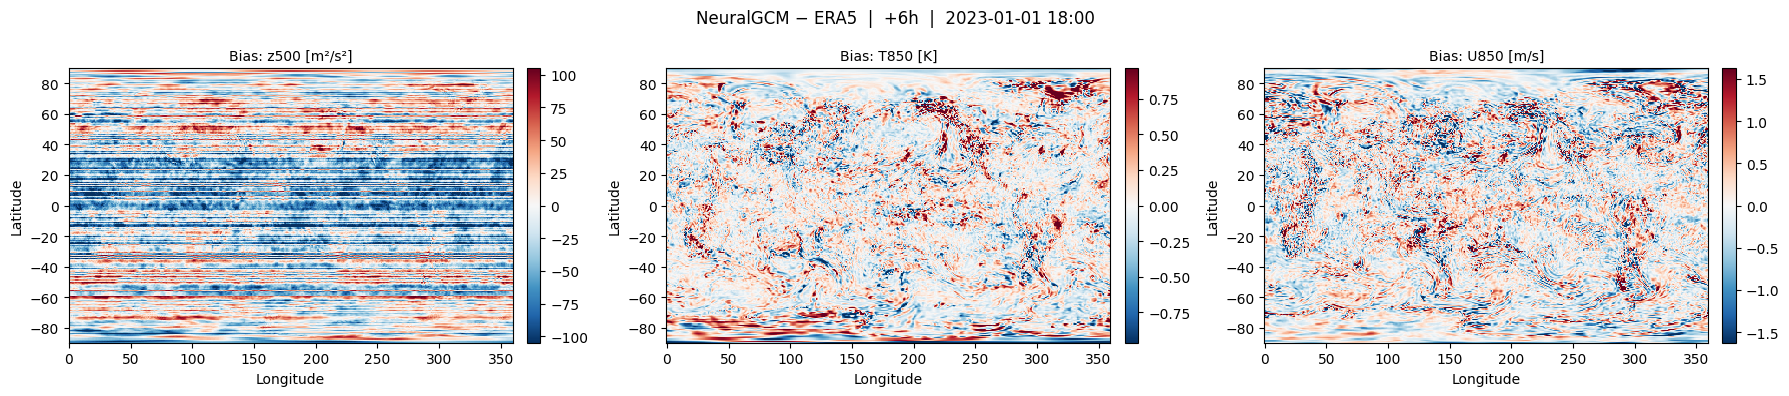

In [12]:
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))

for ax, (var, lev, title, _) in zip(axes2, PLOT_VARS):
    bias = (pred_6h[var].sel(level=lev).squeeze().values -
            ds_gt_native[var].sel(level=lev).squeeze().values).T  # (lat, lon)
    vmax = np.percentile(np.abs(bias), 98)
    im = ax.pcolormesh(lon, lat, bias, cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_title(f'Bias: {title}', fontsize=10)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    fig2.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

plt.suptitle(f'NeuralGCM − ERA5  |  +{LEAD_HOURS}h  |  {valid_time.strftime("%Y-%m-%d %H:00")}',
             fontsize=12)
plt.tight_layout()
bias_path = BASE / 'outputs' / 'neuralgcm' / f'demo_bias_{INIT_DATE}.png'
plt.savefig(bias_path, dpi=120, bbox_inches='tight')
print(f'Saved: {bias_path}')
plt.show()

## 9. Zonal-mean bias (latitude profile)

Shows whether the stripe artifacts are latitude-dependent systematic biases.

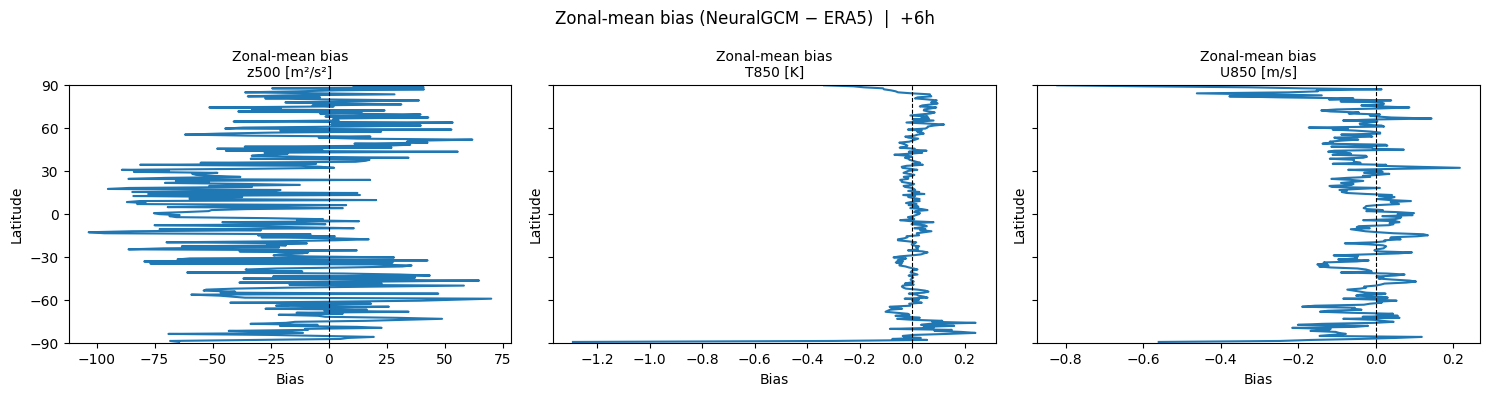

In [13]:
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (var, lev, title, _) in zip(axes3, PLOT_VARS):
    bias = (pred_6h[var].sel(level=lev).squeeze().values -
            ds_gt_native[var].sel(level=lev).squeeze().values)   # (lon, lat)
    zonal_mean = bias.mean(axis=0)                               # (lat,)
    ax.plot(zonal_mean, lat, lw=1.5)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_title(f'Zonal-mean bias\n{title}', fontsize=10)
    ax.set_xlabel('Bias'); ax.set_ylabel('Latitude')
    ax.set_ylim(-90, 90)
    ax.set_yticks(range(-90, 91, 30))

plt.suptitle(f'Zonal-mean bias (NeuralGCM − ERA5)  |  +{LEAD_HOURS}h', fontsize=12)
plt.tight_layout()
plt.show()